# Figure 1 – Methodological workflow (drawn in Python / Matplotlib)

**Comparative Evaluation of Traditional, Machine Learning, Deep Learning, and Hybrid Models for Short-Term Wind Speed Forecasting in Colombo, Sri Lanka**

This notebook re-creates the workflow diagram (Fig. 1) **entirely with Matplotlib primitives** (rounded boxes, circles, polygons, lines and text). No generative-AI tool or raster image is used, so the figure complies with the Springer Nature policy on generative-AI images.

**How to use**
1. Run the cells top to bottom (Kernel → Restart & Run All).
2. Edit the `CONFIG` dictionary in the setup cell if any numbers/labels change (period, number of observations, train/test description, etc.).
3. The last code cell exports the figure as PNG (600 dpi), PDF (vector), SVG (vector) and TIFF (300 dpi).

Only `numpy` and `matplotlib` are required: `pip install numpy matplotlib`.

## 1. Imports, style and editable configuration

In [1]:
%matplotlib inline
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import (FancyBboxPatch, Circle, Rectangle, Ellipse,
                                Polygon, Wedge)

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "Liberation Sans", "DejaVu Sans"],
    "pdf.fonttype": 42,      # embed TrueType fonts (journal-friendly)
    "ps.fonttype": 42,
})

# ------------------------------------------------------------------
# EDIT THESE VALUES so the figure matches the current manuscript
# ------------------------------------------------------------------
CONFIG = dict(
    title      = ("Comparative Evaluation of Traditional, Machine Learning,\n"
                  "Deep Learning, and Hybrid Models\n"
                  "for Short-Term Wind Speed Forecasting in Colombo, Sri Lanka"),
    period     = "Jan 2013 \u2013 Dec 2023",
    location   = "Colombo, Sri Lanka",
    n_obs      = "4,018 daily obs \u2022 10 variables",
    train_txt  = "Training: 2013\u20132021 (3,215 obs)",
    test_txt   = ["Test: 2021\u20132023 (803 obs,", "unseen)"],
    split_txt  = "Chronological 80/20 split",
)

# Colour palette (panel edge, panel fill, number-badge)
PAL = {
    1: ("#2456b8", "#edf3fd", "#1b3f94"),   # blue
    2: ("#e8590c", "#fdf0e8", "#e8590c"),   # orange
    3: ("#5a8f3d", "#f1f7ec", "#4a7d2f"),   # green
    4: ("#e6a100", "#fef8e6", "#e6a100"),   # gold
    5: ("#6b52b5", "#f3f0fa", "#5b4599"),   # purple
    6: ("#d9435a", "#fdeff1", "#d9435a"),   # crimson
    7: ("#1a9a8a", "#eaf7f5", "#1a9a8a"),   # teal
}
FONT_SCALE = 1.06   # global text scaling (raise/lower if text looks tight)

# DejaVu Sans (matplotlib's fallback font) is wider than Arial/Helvetica,
# so shrink the text slightly if that is the font that will actually be used.
from matplotlib import font_manager as fm
_font_file = fm.findfont(fm.FontProperties(family=["sans-serif"]))
if "DejaVu" in _font_file:
    FONT_SCALE *= 0.88
print("Matplotlib", mpl.__version__, "| Font used:", os.path.basename(_font_file), "| FONT_SCALE =", round(FONT_SCALE, 3))
INK   = "#222222"
NAVY  = "#0f1b33"


Matplotlib 3.10.0 | Font used: LiberationSans-Regular.ttf | FONT_SCALE = 1.06


## 2. Drawing helpers
The canvas uses pixel-like coordinates (1320 × 1190) with the **y-axis inverted** (0 = top), so panels can be positioned like on a slide.

In [2]:
# ---------- generic drawing helpers (y-axis is inverted: 0 = top) ----------
def rbox(ax, x, y, w, h, ec, fc, lw=1.8, r=16, z=1, ls="-"):
    ax.add_patch(FancyBboxPatch((x, y), w, h,
                 boxstyle=f"round,pad=0,rounding_size={r}",
                 fc=fc, ec=ec, lw=lw, ls=ls, zorder=z))

def T(ax, x, y, s, size=9.5, color=INK, weight="normal", ha="left",
      va="center", z=6, **kw):
    return ax.text(x, y, s, fontsize=size*FONT_SCALE, color=color, fontweight=weight,
                   ha=ha, va=va, zorder=z, **kw)

def bullets(ax, x, y, items, dy=26, size=9.5, color=INK, dot=True, gap=0):
    """Draw bullet items; '\n' inside an item = continuation line.
    Returns the y position after the last line."""
    for it in items:
        for k, line in enumerate(it.split("\n")):
            if k == 0 and dot:
                ax.add_patch(Circle((x, y), 2.6, fc=color, ec="none", zorder=6))
            T(ax, x + 16, y, line, size=size, color=color)
            y += dy
        y += gap
    return y

def block_arrow(ax, x1, y1, x2, y2, tw=12, hw=34, hl=26, color=NAVY):
    d = np.array([x2 - x1, y2 - y1], float)
    L = np.hypot(*d); u = d / L; n = np.array([-u[1], u[0]])
    p0 = np.array([x1, y1], float); p1 = np.array([x2, y2], float)
    pb = p0 + u * (L - hl)
    pts = [p0 + n*tw/2, pb + n*tw/2, pb + n*hw/2, p1,
           pb - n*hw/2, pb - n*tw/2, p0 - n*tw/2]
    ax.add_patch(Polygon(pts, closed=True, fc=color, ec="none", zorder=5))

def small_arrow(ax, x1, x2, y, color=INK):
    ax.annotate("", xy=(x2, y), xytext=(x1, y),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=1.4,
                                shrinkA=0, shrinkB=0, mutation_scale=11),
                zorder=6)

def panel(ax, n, x, y, w, h, title, title_xy, ha="left", badge_xy=None,
          title_size=13):
    ec, fc, badge = PAL[n]
    rbox(ax, x, y, w, h, ec, fc, lw=1.8, r=22)
    bx, by = badge_xy if badge_xy else (x + 38, y + 40)
    ax.add_patch(Circle((bx, by), 30, fc=badge, ec="white", lw=2, zorder=6))
    T(ax, bx, by + 1, f"{n:02d}", size=17, color="white", weight="bold",
      ha="center")
    T(ax, title_xy[0], title_xy[1], title, size=title_size, weight="bold",
      ha=ha, linespacing=1.35)
    return ec

def chip(ax, x, y, w, h, label, ec="#9fd8d0", fc="#d5eeea"):
    rbox(ax, x, y, w, h, ec, fc, lw=1, r=6)
    T(ax, x + w/2, y + h/2, label, size=9.5, color="#33443f", ha="center")


## 3. Small vector icons
Every icon is built from basic shapes (rectangles, circles, wedges, polygons).

In [3]:
# ---------- small vector icons (all drawn with matplotlib patches) ----------
def ic_calendar(ax, cx, cy, s, c):
    ax.add_patch(FancyBboxPatch((cx-s/2, cy-s/2+3), s, s-3,
                 boxstyle="round,pad=0,rounding_size=3", fc="white", ec=c, lw=1.6, zorder=6))
    ax.add_patch(Rectangle((cx-s/2, cy-s/2+3), s, s*0.27, fc=c, ec=c, zorder=7))
    for i in range(3):
        for j in range(2):
            ax.add_patch(Rectangle((cx-s*0.34+i*s*0.25, cy+s*0.0+j*s*0.24),
                                   s*0.14, s*0.13, fc=c, ec="none", zorder=7))
    for dx in (-0.22, 0.22):
        ax.plot([cx+dx*s]*2, [cy-s/2-1, cy-s/2+7], color=c, lw=2, zorder=8)

def ic_pin(ax, cx, cy, s, c):
    ax.add_patch(Polygon([[cx-s*.3, cy-s*.02], [cx+s*.3, cy-s*.02], [cx, cy+s*.5]],
                         fc=c, ec=c, zorder=6))
    ax.add_patch(Circle((cx, cy-s*.15), s*.34, fc=c, ec=c, zorder=6))
    ax.add_patch(Circle((cx, cy-s*.15), s*.13, fc="white", ec="none", zorder=7))

def ic_db(ax, cx, cy, s, c):
    for k in (2, 1, 0):
        ax.add_patch(Ellipse((cx, cy-s*.28+k*s*.28), s*.85, s*.26,
                             fc=c, ec="white", lw=1.2, zorder=6+(2-k)*0.1))

def ic_people(ax, cx, cy, s, c):
    for dx, sc in ((-0.2, 1.0), (0.22, 0.85)):
        x0 = cx + dx*s
        ax.add_patch(Circle((x0, cy-s*.22), s*.17*sc, fc=c, ec="white", lw=1, zorder=6))
        ax.add_patch(Wedge((x0, cy+s*.42), s*.36*sc, 180, 360, fc=c, ec="white", lw=1, zorder=6))

def ic_gear(ax, cx, cy, s, c):
    n = 8; pts = []
    for k in range(n*4):
        a = 2*np.pi*k/(n*4)
        r = s*.5 if (k % 4) in (0, 1) else s*.36
        pts.append((cx+r*np.cos(a), cy+r*np.sin(a)))
    ax.add_patch(Polygon(pts, fc=c, ec=c, zorder=6))
    ax.add_patch(Circle((cx, cy), s*.16, fc="white", ec="none", zorder=7))

def ic_table(ax, cx, cy, s, c):
    ax.add_patch(FancyBboxPatch((cx-s/2, cy-s/2), s, s, boxstyle="round,pad=0,rounding_size=3",
                                fc="white", ec=c, lw=1.6, zorder=6))
    for f in (-0.17, 0.17):
        ax.plot([cx-s/2, cx+s/2], [cy+f*s]*2, color=c, lw=1.2, zorder=7)
    ax.plot([cx-s*.05]*2, [cy-s/2, cy+s/2], color=c, lw=1.2, zorder=7)
    ax.add_patch(Rectangle((cx-s/2, cy-s/2), s, s*.33, fc=c, ec=c, alpha=.85, zorder=7))

def ic_clock(ax, cx, cy, s, c):
    ax.add_patch(Circle((cx, cy), s*.46, fc="white", ec=c, lw=1.8, zorder=6))
    ax.plot([cx, cx], [cy, cy-s*.28], color=c, lw=1.6, zorder=7)
    ax.plot([cx, cx+s*.2], [cy, cy+s*.1], color=c, lw=1.6, zorder=7)

def ic_bars(ax, cx, cy, s, c, trend=True):
    hs = [.35, .55, .8, .5]
    for i, h in enumerate(hs):
        ax.add_patch(Rectangle((cx-s*.46+i*s*.24, cy+s*.45-h*s), s*.16, h*s,
                               fc="white", ec=c, lw=1.5, zorder=6))
    if trend:
        ax.plot([cx-s*.5, cx-s*.15, cx+s*.1, cx+s*.5],
                [cy+s*.05, cy-s*.15, cy-s*.05, cy-s*.5], color=c, lw=1.6, zorder=7)

def ic_doc(ax, cx, cy, s, c):
    w, h, f = s*.75, s, s*.25
    pts = [(cx-w/2, cy-h/2), (cx+w/2-f, cy-h/2), (cx+w/2, cy-h/2+f),
           (cx+w/2, cy+h/2), (cx-w/2, cy+h/2)]
    ax.add_patch(Polygon(pts, fc="white", ec=c, lw=1.6, zorder=6))
    for k in range(4):
        ax.plot([cx-w*.32, cx+w*.32], [cy-h*.12+k*h*.17]*2, color=c, lw=1.3, zorder=7)

def ic_network(ax, cx, cy, s, c, hub=True):
    nodes = [(-.4, -.3), (-.4, .3), (0, -.42), (0, 0), (0, .42), (.4, -.3), (.4, .3)]
    for i, a in enumerate(nodes):
        for j, b in enumerate(nodes):
            if a[0] < b[0]:
                ax.plot([cx+a[0]*s, cx+b[0]*s], [cy+a[1]*s, cy+b[1]*s],
                        color=c, lw=.7, alpha=.55, zorder=6)
    for a in nodes:
        ax.add_patch(Circle((cx+a[0]*s, cy+a[1]*s), s*.075, fc=c, ec="white", lw=.6, zorder=7))

def ic_brain(ax, cx, cy, s, c):
    for dx, dy, r in ((-.18, -.12, .3), (.18, -.12, .3), (-.2, .16, .28), (.2, .16, .28)):
        ax.add_patch(Circle((cx+dx*s, cy+dy*s), r*s, fc="white", ec=c, lw=1.6, zorder=6))
    ax.plot([cx, cx], [cy-s*.4, cy+s*.4], color=c, lw=1.2, zorder=7)
    ax.plot([cx-s*.25, cx-s*.05], [cy-s*.12, cy+s*.02], color=c, lw=1.2, zorder=7)
    ax.plot([cx+s*.25, cx+s*.05], [cy-s*.12, cy+s*.02], color=c, lw=1.2, zorder=7)

def ic_target(ax, cx, cy, s, c):
    for r, f in ((.46, "white"), (.32, "white"), (.18, c)):
        ax.add_patch(Circle((cx, cy), s*r, fc=f, ec=c, lw=1.6, zorder=6))
    ax.plot([cx, cx+s*.5], [cy, cy-s*.5], color=c, lw=2, zorder=8)
    ax.add_patch(Polygon([[cx+s*.5, cy-s*.5], [cx+s*.36, cy-s*.5], [cx+s*.5, cy-s*.36]],
                         fc=c, ec=c, zorder=8))

def ic_trophy(ax, cx, cy, s, c):
    ax.add_patch(Polygon([[cx-s*.3, cy-s*.42], [cx+s*.3, cy-s*.42],
                          [cx+s*.22, cy+s*.05], [cx-s*.22, cy+s*.05]], fc=c, ec=c, zorder=6))
    for sgn in (-1, 1):
        ax.add_patch(Wedge((cx+sgn*s*.3, cy-s*.24), s*.16, -90 if sgn > 0 else 90,
                           90 if sgn > 0 else 270, width=s*.05, fc=c, ec=c, zorder=6))
    ax.add_patch(Rectangle((cx-s*.05, cy+s*.05), s*.1, s*.22, fc=c, ec=c, zorder=6))
    ax.add_patch(Rectangle((cx-s*.24, cy+s*.27), s*.48, s*.13, fc=c, ec=c, zorder=6))

def ic_scale(ax, cx, cy, s, c):
    ax.plot([cx, cx], [cy-s*.45, cy+s*.4], color=c, lw=2, zorder=6)
    ax.plot([cx-s*.42, cx+s*.42], [cy-s*.32, cy-s*.32], color=c, lw=2, zorder=6)
    for sgn in (-1, 1):
        x0 = cx + sgn*s*.42
        ax.plot([x0, x0-s*.2], [cy-s*.32, cy+s*.1], color=c, lw=1.1, zorder=6)
        ax.plot([x0, x0+s*.2], [cy-s*.32, cy+s*.1], color=c, lw=1.1, zorder=6)
        ax.add_patch(Wedge((x0, cy+s*.1), s*.24, 0, 180, fc=c, ec=c, zorder=6))
    ax.add_patch(Rectangle((cx-s*.22, cy+s*.4), s*.44, s*.08, fc=c, ec=c, zorder=6))

def ic_chat(ax, cx, cy, s, c):
    ax.add_patch(FancyBboxPatch((cx-s*.5, cy-s*.42), s, s*.7,
                 boxstyle="round,pad=0,rounding_size=6", fc="white", ec=c, lw=1.8, zorder=6))
    ax.add_patch(Polygon([[cx-s*.2, cy+s*.27], [cx-s*.32, cy+s*.5], [cx, cy+s*.27]],
                         fc="white", ec=c, lw=1.8, zorder=6))
    for dx in (-.22, 0, .22):
        ax.add_patch(Circle((cx+dx*s, cy-s*.07), s*.055, fc=c, ec="none", zorder=7))

def ic_clip(ax, cx, cy, s, c):
    ax.add_patch(FancyBboxPatch((cx-s*.42, cy-s*.42), s*.84, s*.92,
                 boxstyle="round,pad=0,rounding_size=4", fc="white", ec=c, lw=1.8, zorder=6))
    ax.add_patch(FancyBboxPatch((cx-s*.18, cy-s*.52), s*.36, s*.2,
                 boxstyle="round,pad=0,rounding_size=3", fc=c, ec=c, zorder=7))
    for k in range(3):
        y0 = cy-s*.12+k*s*.23
        ax.plot([cx-s*.28, cx-s*.2, cx-s*.12], [y0, y0+s*.06, y0-s*.06], color=c, lw=1.1, zorder=7)
        ax.plot([cx-s*.02, cx+s*.28], [y0]*2, color=c, lw=1.3, zorder=7)


## 4. Build and display the figure
Panels 01–07 follow the pipeline: data → preprocessing → features/lags → validation → standalone models → hybrid residual correction → evaluation.

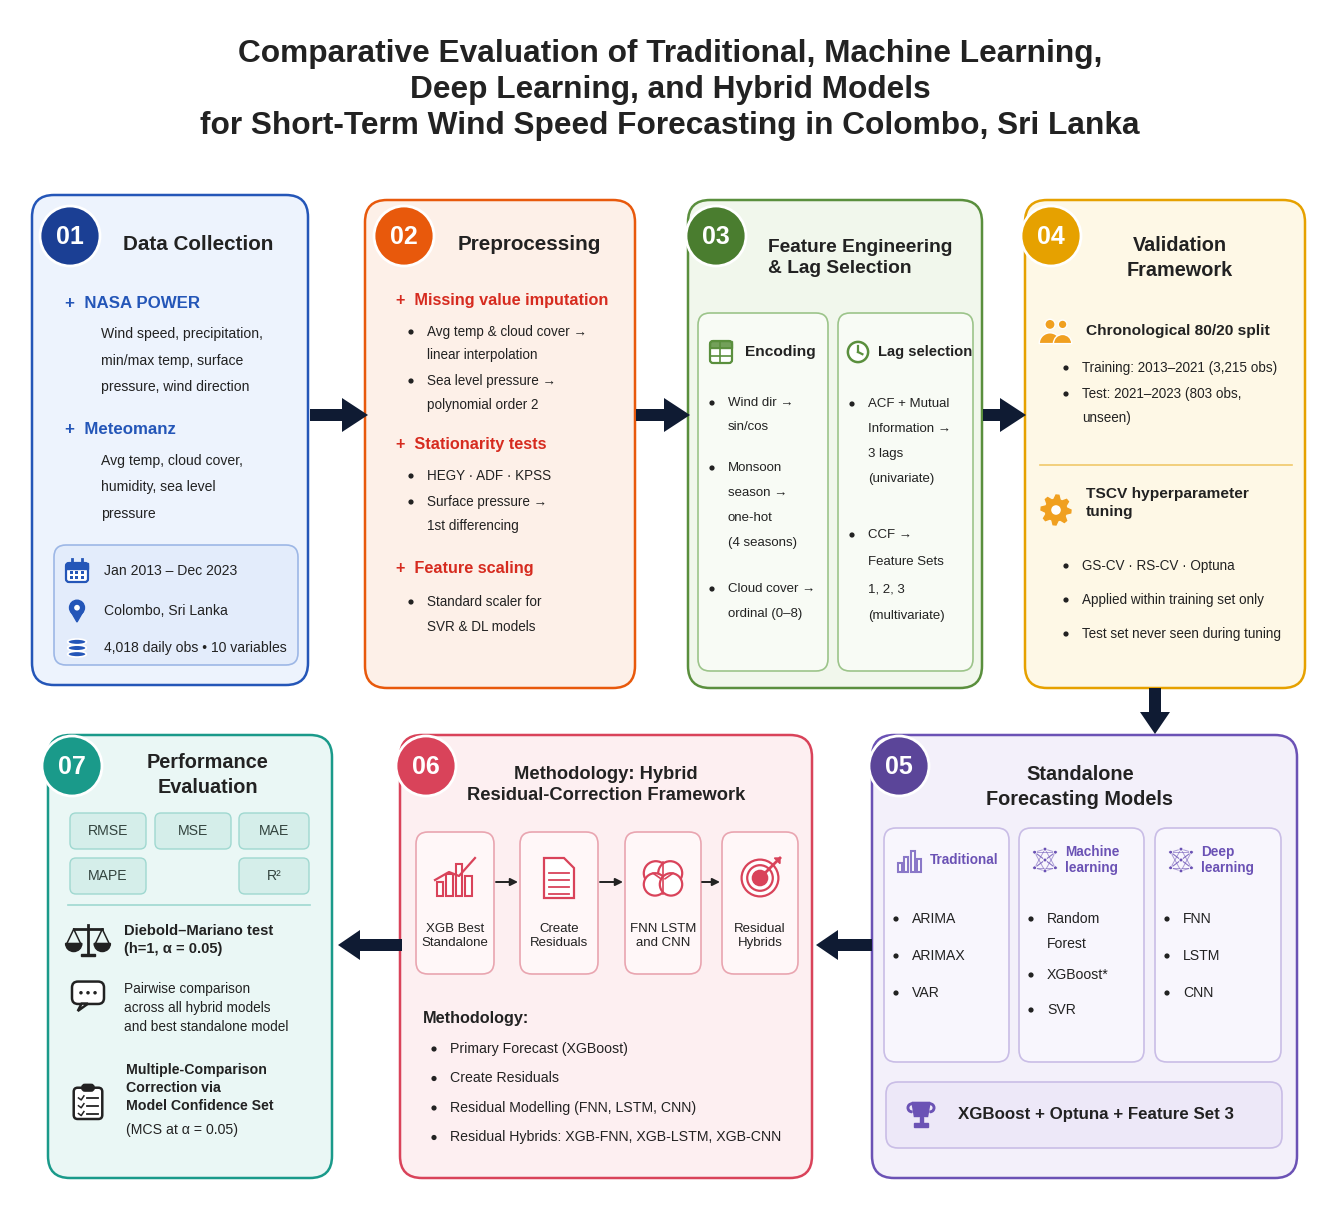

In [4]:
def build_figure(cfg=CONFIG, figsize=(13.2, 11.9)):
    fig = plt.figure(figsize=figsize, facecolor="white")
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_xlim(0, 1320); ax.set_ylim(1190, 0); ax.axis("off")

    # ---------------- Title ----------------
    T(ax, 660, 80, cfg["title"], size=21.5, weight="bold", ha="center",
      linespacing=1.25)

    # =============== 01  DATA COLLECTION ===============
    ec = panel(ax, 1, 22, 185, 276, 490, "Data Collection", (113, 234),
               badge_xy=(60, 226), title_size=14)
    T(ax, 55, 293, "+  NASA POWER", size=11.5, color=ec, weight="bold")
    bullets(ax, 75, 324, ["Wind speed, precipitation,\nmin/max temp, surface\npressure, wind direction"],
            dy=26.5, dot=False)
    T(ax, 55, 420, "+  Meteomanz", size=11.5, color=ec, weight="bold")
    bullets(ax, 75, 451, ["Avg temp, cloud cover,\nhumidity, sea level\npressure"],
            dy=26.5, dot=False)
    rbox(ax, 44, 535, 244, 120, "#9db7e6", "#e3ecfb", lw=1.2, r=12)
    ic_calendar(ax, 67, 561, 22, ec);  T(ax, 94, 561, cfg["period"], size=9.5)
    ic_pin(ax, 67, 601, 22, ec);       T(ax, 94, 601, cfg["location"], size=9.5)
    ic_db(ax, 67, 638, 22, ec);        T(ax, 94, 638, cfg["n_obs"], size=9.5)

    # =============== 02  PREPROCESSING ===============
    ec = panel(ax, 2, 355, 190, 270, 488, "Preprocessing", (448, 234),
               badge_xy=(394, 226), title_size=14)
    red = "#d62b1f"
    T(ax, 386, 291, "+  Missing value imputation", size=11, color=red, weight="bold")
    bullets(ax, 401, 322, ["Avg temp & cloud cover \u2192\nlinear interpolation",
                           "Sea level pressure \u2192\npolynomial order 2"], dy=23.5, gap=2, size=9.2)
    T(ax, 386, 434, "+  Stationarity tests", size=11, color=red, weight="bold")
    bullets(ax, 401, 466, ["HEGY \u00b7 ADF \u00b7 KPSS"], dy=24, size=9.2)
    bullets(ax, 401, 492, ["Surface pressure \u2192\n1st differencing"], dy=24, size=9.2)
    T(ax, 386, 559, "+  Feature scaling", size=11, color=red, weight="bold")
    bullets(ax, 401, 592, ["Standard scaler for\nSVR & DL models"], dy=25, size=9.2)

    # =============== 03  FEATURE ENGINEERING ===============
    ec = panel(ax, 3, 678, 190, 294, 488, "Feature Engineering\n& Lag Selection",
               (758, 248), badge_xy=(706, 226), title_size=13)
    rbox(ax, 688, 303, 130, 358, "#9cc48a", "#f8fbf5", lw=1.2, r=12)
    rbox(ax, 828, 303, 135, 358, "#9cc48a", "#f8fbf5", lw=1.2, r=12)
    ic_table(ax, 711, 342, 22, ec);  T(ax, 735, 342, "Encoding", size=10.5, weight="bold")
    bullets(ax, 702, 393, ["Wind dir \u2192\nsin/cos"], dy=24, size=9)
    bullets(ax, 702, 458, ["Monsoon\nseason \u2192\none-hot\n(4 seasons)"], dy=25, size=9)
    bullets(ax, 702, 579, ["Cloud cover \u2192\nordinal (0\u20138)"], dy=25, size=9)
    ic_clock(ax, 848, 342, 22, ec);  T(ax, 868, 342, "Lag selection", size=10, weight="bold")
    bullets(ax, 842, 394, ["ACF + Mutual\nInformation \u2192\n3 lags\n(univariate)"], dy=25, size=9)
    bullets(ax, 842, 525, ["CCF \u2192\nFeature Sets\n1, 2, 3\n(multivariate)"], dy=27, size=9)

    # =============== 04  VALIDATION ===============
    ec = panel(ax, 4, 1015, 190, 280, 488, "Validation\nFramework", (1170, 248),
               ha="center", badge_xy=(1041, 226), title_size=13.5)
    ic_people(ax, 1046, 321, 30, "#f0a020")
    T(ax, 1076, 321, cfg["split_txt"], size=10.5, weight="bold")
    bullets(ax, 1056, 358, [cfg["train_txt"]], dy=24, size=9.2)
    bullets(ax, 1056, 384, ["\n".join(cfg["test_txt"])], dy=24, size=9.2)
    ax.plot([1030, 1282], [455, 455], color="#f0c96a", lw=1.2, zorder=6)
    ic_gear(ax, 1046, 500, 30, "#f0a020")
    T(ax, 1076, 493, "TSCV hyperparameter\ntuning", size=10.5, weight="bold", linespacing=1.35)
    bullets(ax, 1056, 556, ["GS-CV \u00b7 RS-CV \u00b7 Optuna", "Applied within training set only",
                            "Test set never seen during tuning"], dy=34, size=9.2)

    # =============== 05  STANDALONE MODELS ===============
    ec = panel(ax, 5, 862, 725, 425, 443, "Standalone\nForecasting Models",
               (1070, 777), ha="center", badge_xy=(889, 756), title_size=13.5)
    cols = [(874, 125, "Traditional", ["ARIMA", "ARIMAX", "VAR"], ic_bars),
            (1009, 125, "Machine\nlearning", ["Random\nForest", "XGBoost*", "SVR"], ic_network),
            (1145, 126, "Deep\nlearning", ["FNN", "LSTM", "CNN"], ic_network)]
    for x0, w, ttl, items, icon in cols:
        rbox(ax, x0, 818, w, 234, "#c9bde6", "#f8f6fd", lw=1.2, r=12)
        icon(ax, x0+26, 850, 26, ec) if icon is ic_network else icon(ax, x0+26, 850, 26, "#8a78c8", trend=False)
        T(ax, x0+46, 850, ttl, size=9.3, weight="bold", color=ec, linespacing=1.2)
    bullets(ax, 886, 909, ["ARIMA"], dy=36, size=9.5)
    bullets(ax, 886, 946, ["ARIMAX"], dy=36, size=9.5)
    bullets(ax, 886, 983, ["VAR"], dy=36, size=9.5)
    bullets(ax, 1021, 909, ["Random\nForest"], dy=25, size=9.5)
    bullets(ax, 1021, 965, ["XGBoost*"], dy=36, size=9.5)
    bullets(ax, 1021, 1000, ["SVR"], dy=36, size=9.5)
    bullets(ax, 1157, 909, ["FNN"], dy=36, size=9.5)
    bullets(ax, 1157, 946, ["LSTM"], dy=36, size=9.5)
    bullets(ax, 1157, 983, ["CNN"], dy=36, size=9.5)
    rbox(ax, 876, 1072, 396, 66, "#c9bde6", "#ede8f8", lw=1.2, r=12)
    ic_trophy(ax, 911, 1105, 30, ec)
    T(ax, 948, 1105, "XGBoost + Optuna + Feature Set 3", size=11.5, weight="bold")

    # =============== 06  HYBRID RESIDUAL-CORRECTION ===============
    ec = panel(ax, 6, 390, 725, 412, 443, "Methodology: Hybrid\nResidual-Correction Framework",
               (596, 775), ha="center", badge_xy=(416, 756), title_size=12.5)
    boxes = [(406, 78, "XGB Best\nStandalone", ic_bars), (510, 78, "Create\nResiduals", ic_doc),
             (615, 76, "FNN LSTM\nand CNN", ic_brain), (712, 76, "Residual\nHybrids", ic_target)]
    for x0, w, lab, icon in boxes:
        rbox(ax, x0, 822, w, 142, "#e9a5b0", "#fff7f8", lw=1.2, r=12)
        icon(ax, x0+w/2, 868, 40, ec)
        T(ax, x0+w/2, 926, lab, size=9, ha="center", linespacing=1.3)
    for xa, xb in ((486, 508), (590, 613), (692, 710)):
        small_arrow(ax, xa, xb, 872)
    T(ax, 413, 1008, "Methodology:", size=11, weight="bold")
    bullets(ax, 424, 1039, ["Primary Forecast (XGBoost)", "Create Residuals",
                            "Residual Modelling (FNN, LSTM, CNN)",
                            "Residual Hybrids: XGB-FNN, XGB-LSTM, XGB-CNN"], dy=29.5, size=9.6)

    # =============== 07  PERFORMANCE EVALUATION ===============
    ec = panel(ax, 7, 38, 725, 284, 443, "Performance\nEvaluation", (198, 765),
               ha="center", badge_xy=(62, 756), title_size=13.5)
    chip(ax, 60, 803, 76, 36, "RMSE");  chip(ax, 145, 803, 76, 36, "MSE");  chip(ax, 229, 803, 70, 36, "MAE")
    chip(ax, 60, 848, 76, 36, "MAPE");  chip(ax, 229, 848, 70, 36, "R\u00b2")
    ax.plot([58, 300], [895, 895], color="#9fd8d0", lw=1.2, zorder=6)
    ic_scale(ax, 78, 930, 34, INK)
    T(ax, 114, 930, "Diebold\u2013Mariano test\n(h=1, \u03b1 = 0.05)", size=10, weight="bold", linespacing=1.4)
    ic_chat(ax, 78, 985, 32, INK)
    T(ax, 114, 998, "Pairwise comparison\nacross all hybrid models\nand best standalone model", size=9.3, linespacing=1.45)
    ic_clip(ax, 78, 1092, 34, INK)
    T(ax, 116, 1078, "Multiple-Comparison\nCorrection via\nModel Confidence Set", size=9.6,
      weight="bold", linespacing=1.4)
    T(ax, 116, 1120, "(MCS at \u03b1 = 0.05)", size=9.6)
    # ---------------- Flow arrows ----------------
    block_arrow(ax, 300, 405, 358, 405)
    block_arrow(ax, 626, 405, 680, 405)
    block_arrow(ax, 973, 405, 1016, 405)
    block_arrow(ax, 1145, 678, 1145, 724, hl=22, hw=30)
    block_arrow(ax, 862, 935, 806, 935, hl=22, hw=30)
    block_arrow(ax, 392, 935, 328, 935, hl=22, hw=30)
    return fig

fig = build_figure()
plt.show()


## 5. Export for the journal
PDF/SVG are vector formats; PNG/TIFF are high-resolution rasters.

In [5]:
from pathlib import Path

out = Path("figure_outputs"); out.mkdir(exist_ok=True)
fig.savefig(out / "Figure1_workflow.png", dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out / "Figure1_workflow.pdf", bbox_inches="tight", facecolor="white")   # vector
fig.savefig(out / "Figure1_workflow.svg", bbox_inches="tight", facecolor="white")   # vector
fig.savefig(out / "Figure1_workflow.tiff", dpi=300, bbox_inches="tight", facecolor="white",
            pil_kwargs={"compression": "tiff_lzw"})
print("Saved:", sorted(p.name for p in out.iterdir()))

Saved: ['Figure1_workflow.pdf', 'Figure1_workflow.png', 'Figure1_workflow.svg', 'Figure1_workflow.tiff']


## 6. Suggested wording for the editor (Figure 1 provenance)

> **Figure 1.** The workflow diagram submitted in the earlier version was generated with a generative-AI image tool (ChatGPT). In line with Springer Nature's policy on generative-AI images, we have removed it and re-created the figure from scratch. The new Figure 1 was produced programmatically in Python using Matplotlib (version printed in the setup cell above; run in Jupyter Notebook). All rectangles, icons, arrows and text are drawn with Matplotlib primitives (`FancyBboxPatch`, `Circle`, `Polygon`, `Wedge`, `ax.text`, etc.); no AI-generated imagery is included. The notebook (`Figure1_workflow.ipynb`) is provided in the code repository and the figure is exported as vector PDF/SVG and 300–600 dpi PNG/TIFF.

*Tip:* for the "screenshots" the editor asks for, capture (i) the notebook code cells and (ii) the rendered figure output from this notebook.